In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import h5py as h5
import pandas as pd
from astropy.cosmology import FlatLambdaCDM, z_at_value
from scipy.stats import spearmanr
import eagle_tools
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os
print(os.getcwd())
import sys
sys.path.insert(0, '.')  # current folder first

notebook_dir = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/scripts'
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

import shap
import windowshap

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import minmax_scale, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy.stats import spearmanr, binned_statistic
import time
import timeit
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import seaborn as sns

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Use custom matplotlib template
plt.style.use('/users/arirrobe/MachineLearning/MBH-EBind-MorphoKinem/mnras_mpl.stylesheet')

cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089)

omega_b = 0.0482519
omega_0 = 0.307
omega_lambda = 0.693
Z_solar = 0.012663729
M_solar = 1.98841e33
eps_r = 0.1
eps_f = 0.15
c = 2.99792458e10
yr = 3.154e7
H_0 = 67.77
H_0_cgs = 3.2407789e-18
Mpc = 3.086e24 
kpc = 3.086e21
pc = 3.086e18
G = 6.67e-8
km = 1e5
h = 0.6777
boxsize = 67770/h
Z_w = 0.002
gamma_wz = 2
f_wz = 0.25
ebar_w = 3.6
N_SNII = 0.0118
rho_crit =  8.6e-30 #g/cm^3 given by 3H^2/8piG

cgs_conv_mass = 1.989e+43
cgs_conv_sfr = 6.304278922345484e+25
cgs_conv_birthdensity = 6.769911178294543e-31
cgs_conv_acc_rate = 6.445909132449984e+23
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21

dm_particlemass = 9.7e6*M_solar

load_path = '/users/arirrobe/MachineLearning/EAGLE_Datasets'
archive_load_path = '/mnt/scratch/users/arijdavi/hpcdata0_backup/EAGLE_catalogues/L0100N1504/REFERENCE/028_z000p000'
save_path = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/outputs/windowSHAP'

/users/arirrobe/MachineLearning


In [65]:
with h5.File(f'{load_path}/L0100N1504_AllHaloProperties.h5', 'r') as fi:
    matched_group_nums = fi['/GroupNumber'][()].astype(np.int32)
    kappa_co = fi['kappa_co'][()]
    e_agn = fi['E_AGN'][()]
    e_bind = fi['E_Bind'][()]
    assembly_time = fi['AssemblyTime'][()]
    conc = fi['Vmax_V200'][()]
    m200 = fi['M200'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_NewFeedback.h5', 'r') as fi:
    group_nums = fi['/GroupNumber'][()].astype(np.int64)
    m_bh = fi['/M_BH_INTERP/'][()][:,0]
fi.close()

with h5.File(f'{load_path}/L0100N1504_MorphoKinem.h5', 'r') as fi:
    all_morpho_kinem = fi['AllMorphoKinem'][()]
    all_morpho_z = fi['AllMorphoKinem'][()][:,1]
    all_ellipticity = fi['AllMorphoKinem'][()][:,3]
    all_triaxiality = fi['AllMorphoKinem'][()][:,4]
fi.close()

with h5.File(f'{load_path}/L0100N1504_All_DiscToTotal.h5', 'r') as fi:
    all_disc_to_total = fi['All_DiscToTotal'][()]
fi.close()

with h5.File(f'{load_path}/L0100N1504_kappa_gas.h5', 'r') as fi:
    all_kappa_gas = fi['kappa_gas'][()]
fi.close()

all_kappa = np.array(pd.read_csv(f'{load_path}/AllKappaInfo.csv', index_col=0, skiprows=0))

missing_idx = []
for i, gn in enumerate(matched_group_nums):
    if gn == 1:
        all_z = all_kappa[all_kappa[:,0] == gn, 1]
    
    galaxy = all_kappa[all_kappa[:,0] == gn]
    if galaxy.shape[0] <= 8:
        missing_idx.append(gn)

missing_idx = np.unique(missing_idx)
print(missing_idx)
print(len(missing_idx))

all_kappa = np.delete(all_kappa, np.argwhere(np.isin(all_kappa[:,0], missing_idx)), 0)
all_kappa_gas = np.delete(all_kappa_gas, np.argwhere(np.isin(all_kappa_gas[:,0], missing_idx)), 0)
all_triaxiality = np.delete(all_triaxiality, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_ellipticity = np.delete(all_ellipticity, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_z = np.delete(all_morpho_z, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_kinem = np.delete(all_morpho_kinem, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_disc_to_total = np.delete(all_disc_to_total, np.argwhere(np.isin(all_disc_to_total[:,0], missing_idx)), 0)

all_kappa_gas[:,2][np.where(np.isnan(all_kappa_gas[:,2]))] = np.min(all_kappa_gas[:,2][np.where(~np.isnan(all_kappa_gas[:,2]))])
all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] == -10)] = np.min(all_kappa_gas[:,2][np.where(all_kappa_gas[:,2] != -10)])
    
kappa_co = all_kappa[all_kappa[:,1]<= 0.001, 2]
kappa_gas = all_kappa_gas[all_kappa_gas[:,1]<= 0.001, 2]
triax_z0 = all_triaxiality[all_morpho_z <= 0.001]
ellip_z0 = all_ellipticity[all_morpho_z <= 0.001]
disc_to_total = all_disc_to_total[all_disc_to_total[:,1] <= 0.001, 2]

all_alpha_m = all_morpho_kinem.copy()[:,:2]
new_col = ((all_ellipticity**2) + 1 - all_triaxiality)/2
all_alpha_m = np.concatenate([all_alpha_m, new_col[:, None]], axis=1)
alpha_m = all_alpha_m[all_alpha_m[:,1] <= 0.001]

idx_in_group_nums = np.array([np.where(group_nums == gn)[0][0] for gn in matched_group_nums])
m_bh = m_bh[idx_in_group_nums]


with h5.File(f'{archive_load_path}/DMO_binding_energies.hdf5', 'r') as fi:
    e_bind_2500 = fi['Particle_E_2500'][()]
    e_bind_gn = fi['GroupNumber'][()]
fi.close()


idx_in_ebind_gn = np.array([np.where(e_bind_gn == gn)[0][0] for gn in matched_group_nums])
e_bind_2500 = e_bind_2500[idx_in_ebind_gn]

with h5.File(f'{load_path}/L0100N1504_Mstar_MBH_Histories.h5', 'r') as fi:
    all_mstar_mbh = fi['Mstar_MBH_Arr'][()]
fi.close()

all_mstar_mbh = np.delete(all_mstar_mbh, np.argwhere(all_mstar_mbh[:,0]==0), 0)
all_mstar_mbh = all_mstar_mbh[np.lexsort((all_mstar_mbh[:,1], all_mstar_mbh[:,0]))]


all_mstar = np.delete(all_mstar_mbh, 2, 1)
all_mbh = all_mstar_mbh[:,:3]
all_mbh[all_mbh[:,1]<= 0.001, 2] = m_bh

all_mstar = np.delete(all_mstar, np.argwhere(np.isin(all_mstar[:,0], missing_idx)), 0)
all_mbh = np.delete(all_mbh, np.argwhere(np.isin(all_mbh[:,0], missing_idx)), 0)

m_star = all_mstar[all_mstar[:,1]<= 0.001, 2]
m_bh = all_mbh[all_mbh[:,1]<= 0.001, 2]

with h5.File(f'{load_path}/L0100N1504_M200_Histories.h5', 'r') as fi:
    all_m200 = fi['M200_Histories'][()]
fi.close()

all_m200[all_m200[:,1]<= 0.001, 2] = m200
all_m200 = np.delete(all_m200, np.argwhere(np.isin(all_m200[:,0], missing_idx)), 0)
# all_m200 = all_m200[np.argwhere((np.isin(all_mbh[:,0], all_m200[:,0])) & (np.isin(all_mbh[:,1], all_m200[:,1]))).ravel()]

pairs_mbh = np.core.records.fromarrays(
    [all_mbh[:,0], all_mbh[:,1]],
    names='group,z'
)

pairs_m200 = np.core.records.fromarrays(
    [all_m200[:,0], all_m200[:,1]],
    names='group,z'
)

mask = np.isin(pairs_m200, pairs_mbh)
all_m200 = all_m200[mask]


with h5.File(f'{load_path}/L0100N1504_30kpcApertureMaxMassAllMergers.h5', 'r') as fi:
    all_mergers = fi['AllMergerEvents'][()]  # (gn, z, major_mergers, minor_mergers, Mstar_Acc, f_exsitu)
fi.close()
all_mergers = np.delete(all_mergers, np.argwhere(np.isin(all_mergers[:,0], missing_idx)), 0)


m200 = np.log10(m200)
all_mstar[:,2] = np.log10(all_mstar[:,2])
all_mbh[:,2] = np.log10(all_mbh[:,2])
all_m200[:,2] = np.log10(all_m200[:,2])
m_star = np.log10(m_star)
m_bh = np.log10(m_bh)
e_agn = np.log10(e_agn)
e_bind = np.log10(np.abs(e_bind))
e_bind_2500 = np.log10(np.abs(e_bind_2500) * cgs_conv_mass*cgs_conv_vel / h)

missing_idx = np.argwhere(np.isin(matched_group_nums, missing_idx)).ravel()
matched_group_nums = np.delete(matched_group_nums, missing_idx)
assembly_time = np.delete(assembly_time, missing_idx)
m200 = np.delete(m200, missing_idx)
e_agn = np.delete(e_agn, missing_idx)
e_bind = np.delete(e_bind, missing_idx)
e_bind_2500 = np.delete(e_bind_2500, missing_idx)
e_bind = e_bind_2500

e_bind_sorted = e_bind[np.argsort(e_bind)]
m_star_ebind = m_star[np.argsort(e_bind)]
matched_group_nums_ebind = matched_group_nums[np.argsort(e_bind)]
m200_ebind = m200[np.argsort(e_bind)]
m_bh_ebind = m_bh[np.argsort(e_bind)]
kappa_co_ebind = kappa_co[np.argsort(e_bind)]
kappa_gas_ebind = kappa_gas[np.argsort(e_bind)]
alpha_m_ebind = alpha_m[np.argsort(e_bind)]
disc_to_total_ebind = disc_to_total[np.argsort(e_bind)]

all_redshifts = all_kappa[all_kappa[:,0]==matched_group_nums[0],1][::-1][:-1]
t_cosmic = cosmology.age(all_redshifts).value
print(all_redshifts)
print(t_cosmic)

n_samples = len(matched_group_nums)
n_timesteps = len(all_redshifts)
n_features = 6

# Initialize X with -10 to mark "missing"
X = np.full((n_samples, n_timesteps, n_features), -10.0, dtype=np.float32)

# Create a mapping from galaxy ID -> row index
group_to_idx = {g: i for i, g in enumerate(matched_group_nums)}

for t_idx, z in enumerate(all_redshifts):
    # kappa_star
    mask = np.isclose(all_kappa[:, 1], z)
    for row in all_kappa[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 0] = row[2]

    # kappa_gas
    mask = np.isclose(all_kappa_gas[:, 1], z)
    for row in all_kappa_gas[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 1] = row[2]

    # alpha_m
    mask = np.isclose(all_alpha_m[:, 1], z)
    for row in all_alpha_m[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 2] = row[2]

    # D/T
    mask = np.isclose(all_disc_to_total[:, 1], z)
    for row in all_disc_to_total[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 3] = row[2]

    # Mstar_Accreted
    mask = np.isclose(all_mergers[:, 1], z)
    for row in all_mergers[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 4] = row[4]

    # f_exsitu
    for row in all_mergers[mask]:
        g = int(row[0])
        if g in group_to_idx:
            X[group_to_idx[g], t_idx, 5] = row[-1]

print("X shape:", X.shape)


ebind_range = (e_bind >= 58) & (e_bind <= 58.5)
low_kappa = np.percentile(kappa_co[ebind_range], 25)
high_kappa = np.percentile(kappa_co[ebind_range], 75)

low_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] <= low_kappa]
high_kappa_ids = matched_group_nums[ebind_range][kappa_co[ebind_range] >= high_kappa]
test_kappa_ids = matched_group_nums[ebind_range][(kappa_co[ebind_range] <= low_kappa) | (kappa_co[ebind_range] >= high_kappa)]

gal_mask_train = ~np.isin(matched_group_nums, test_kappa_ids)
gal_mask_test  = np.isin(matched_group_nums, test_kappa_ids)

# X_train = X[gal_mask_train, :, :]
# X_test  = X[gal_mask_test, :, :]

# y_train = m_bh[gal_mask_train]
# y_test  = m_bh[gal_mask_test]

# Train-test split
y = m_bh

indices = np.arange(X.shape[0])
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)
e_bind_train, e_bind_test = e_bind[indices_train], e_bind[indices_test]
X_train, X_val, y_train, y_val, indices_train, indices_val = train_test_split(X_train, y_train, indices_train, test_size=0.1, shuffle=True, random_state=42)
e_bind_train, e_bind_val = e_bind[indices_train], e_bind[indices_val]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# Copy arrays to avoid overwriting
X_train_scaled = X_train.copy()
X_val_scaled  = X_val.copy()
X_test_scaled  = X_test.copy()

# Scale per feature across all galaxies and timesteps
N, T, F = X_train.shape
scaler = MinMaxScaler(feature_range=(0, 1))

for f in range(F):
    # Flatten the feature across all samples and timesteps
    feature_train = X_train[:, :, f].flatten()
    valid_mask = feature_train > -10

    # Only fit/transform valid values
    feature_train_scaled = np.zeros_like(feature_train)
    feature_train_scaled[valid_mask] = scaler.fit_transform(feature_train[valid_mask].reshape(-1, 1)).flatten()
    feature_train_scaled[~valid_mask] = -10  # keep missing values as -10

    # Put it back
    X_train_scaled[:, :, f] = feature_train_scaled.reshape(N, T)

    # Apply same scaler to validation
    feature_val = X_val[:, :, f].flatten()
    valid_mask_val = feature_val > -10
    feature_val_scaled = np.zeros_like(feature_val)
    feature_val_scaled[valid_mask_val] = scaler.transform(feature_val[valid_mask_val].reshape(-1, 1)).flatten()
    feature_val_scaled[~valid_mask_val] = -10
    X_val_scaled[:, :, f] = feature_val_scaled.reshape(X_val.shape[0], T)
    
    # Apply same scaler to test
    feature_test = X_test[:, :, f].flatten()
    valid_mask_test = feature_test > -10
    feature_test_scaled = np.zeros_like(feature_test)
    feature_test_scaled[valid_mask_test] = scaler.transform(feature_test[valid_mask_test].reshape(-1, 1)).flatten()
    feature_test_scaled[~valid_mask_test] = -10
    X_test_scaled[:, :, f] = feature_test_scaled.reshape(X_test.shape[0], T)

[ 643  741  799  970 1039 1280 1447 1760 1772 1851 2064 2080 2323 2521
 2566 2649 2656 2682 2780 2811 2854 2925 3016 3022 3143 3274 3356 3387
 3424 3469 3547 3615 3643 3702 3777 3952]
36
[4.4852138  3.9836636  3.5279765  3.0165045  2.4784133  2.237037
 2.0124102  1.7369658  1.4867073  1.2593315  1.0041217  0.86505055
 0.7356296  0.6151898  0.5031073  0.36566857 0.27090108 0.18270987
 0.10063854]
[ 1.34472796  1.551595    1.78984634  2.13875274  2.64578454  2.94114736
  3.26795588  3.75748139  4.31472894  4.9464489   5.85033684  6.45755519
  7.11544418  7.82491315  8.58613433  9.68036537 10.55842338 11.48297519
 12.4509065 ]
X shape: (3374, 19, 6)
(2732, 19, 6) (304, 19, 6) (338, 19, 6)
(2732,) (304,) (338,)


In [13]:
class LSTMAttentionRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, bidirectional=False):
        super().__init__()

        self.num_directions = 2 if bidirectional else 1
        self.hidden_dim = hidden_dim

        # LSTM backbone
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        # Attention layer
        self.attention_layer = nn.Linear(hidden_dim * self.num_directions, 1)

        # Output layer
        self.output_layer = nn.Linear(hidden_dim * self.num_directions, 1)

    def forward(self, x):
        """
        x: (batch_size, time_steps, input_dim)
        """
        lstm_out, _ = self.lstm(x)  # (batch_size, time_steps, hidden_dim * num_directions)

        # Compute attention scores
        attn_scores = self.attention_layer(lstm_out).squeeze(-1)  # (batch_size, time_steps)

        # Mask: ignore timesteps where the first feature == -10
        mask = (x[:, :, 0] > -10)  # (batch_size, time_steps)
        attn_scores_masked = attn_scores.masked_fill(~mask, float('-inf'))

        # Softmax over time dimension (valid timesteps only)
        attn_weights = torch.softmax(attn_scores_masked, dim=1).unsqueeze(-1)  # (batch_size, time_steps, 1)

        # Weighted sum of LSTM outputs
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)  # (batch_size, hidden_dim * num_directions)

        # Final regression output
        y_pred = self.output_layer(context_vector)  # (batch_size, 1)
        return y_pred, attn_weights.squeeze(-1)

In [ ]:
def objective(trial):

    # ------------------
    # Hyperparameters to tune
    # ------------------
    hidden_dim = trial.suggest_int("hidden_dim", 32, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # ------------------
    # Initialisation
    # ------------------
    
    input_dim = X_train.shape[2]     # Feature Dimension
    timesteps = X_train.shape[1]     # Time Dimension
    
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
    
    
    # ------------------
    # Model
    # ------------------
    model = LSTMAttentionRegressor(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        bidirectional=False
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ------------------
    # Training loop 
    # ------------------
    n_epochs = 50   # shorter for Optuna
    
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(X_train_tensor.size(0))

        for i in range(0, X_train_tensor.size(0), batch_size):
            idx = perm[i:i+batch_size]
            x_batch = X_train_tensor[idx]
            y_batch = y_train_tensor[idx].view(-1, 1)

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        # ---- validation ----
        model.eval()
        with torch.no_grad():
            val_preds, _ = model(X_val_tensor)
            val_loss = criterion(
                val_preds,
                y_val_tensor.view(-1, 1)
            ).item()

        # Pruning (early stopping for bad trials)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_loss


In [8]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=40)

[I 2026-01-26 13:58:57,691] A new study created in memory with name: no-name-5265eec2-ebbb-45bd-94e0-802c4574cbb0
[I 2026-01-26 14:00:16,279] Trial 0 finished with value: 0.3942286968231201 and parameters: {'hidden_dim': 96, 'num_layers': 4, 'lr': 0.000291063591313307, 'weight_decay': 6.251373574521755e-05, 'batch_size': 16}. Best is trial 0 with value: 0.3942286968231201.
[I 2026-01-26 14:01:47,444] Trial 1 finished with value: 0.1597886085510254 and parameters: {'hidden_dim': 224, 'num_layers': 3, 'lr': 0.0002607024758370766, 'weight_decay': 1.1527987128232402e-06, 'batch_size': 16}. Best is trial 1 with value: 0.1597886085510254.
[I 2026-01-26 14:01:54,284] Trial 2 finished with value: 0.8623758554458618 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'lr': 4.059611610484306e-05, 'weight_decay': 3.752055855124284e-05, 'batch_size': 64}. Best is trial 1 with value: 0.1597886085510254.
[I 2026-01-26 14:02:30,887] Trial 3 finished with value: 0.38906288146972656 and parameters: {'h

In [66]:
# Initialise input parameters for LSTM
input_dim = X_train.shape[2]     # Feature Dimension
timesteps = X_train.shape[1]     # Time Dimension
epochs = 100
batch_size = study.best_params['batch_size']
# hidden_dim = 128
# epochs = 200
# lr = 1e-4

# Model, loss, optimizer
model = LSTMAttentionRegressor(
    input_dim=input_dim,
    hidden_dim=study.best_params['hidden_dim'],
    num_layers=study.best_params['num_layers'],
    bidirectional=False
)

criterion = nn.MSELoss()  # regression loss
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'], weight_decay=study.best_params['weight_decay'])

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)


# Lists to store losses
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.size(0))
    batch_loss = []

    for i in range(0, X_train_tensor.size(0), batch_size):
        idx = perm[i:i+batch_size]
        x_batch = X_train_tensor[idx]
        y_batch = y_train_tensor[idx].view(-1, 1)

        optimizer.zero_grad()
        preds, _ = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    # Average training loss over batches
    avg_train_loss = np.mean(batch_loss)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    with torch.no_grad():
        train_preds, _ = model(X_train_tensor)
        train_preds_np = train_preds.cpu().numpy().flatten()
        train_labels_np = y_train_tensor.cpu().numpy().flatten()
        
        val_preds, val_attention = model(X_val_tensor)
        val_preds_np = val_preds.cpu().numpy().flatten()
        val_labels_np = y_val_tensor.cpu().numpy().flatten()

        val_loss = np.mean((val_preds_np - val_labels_np) ** 2)
        val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train MSE = {avg_train_loss:.3f} | "
        f"Validation MSE = {val_loss:.3f} | "
        f"Train RMSE = {np.sqrt(avg_train_loss):.3f} | "
        f"Validation RMSE = {np.sqrt(val_loss):.3f}"
    )
    
        # Initialize list once
    if epoch == 0:
        attn_history_all = []

    # Save global attention per epoch
    attn_weights_np = val_attention.cpu().numpy()  # (batch_size, timesteps)
    mean_attn_per_timestep = attn_weights_np.mean(axis=0)  # (timesteps,)
    attn_history_all.append(mean_attn_per_timestep.copy())
    
attn_history_all = np.array(attn_history_all)


Epoch 001 | Train MSE = 4.325 | Validation MSE = 0.813 | Train RMSE = 2.080 | Validation RMSE = 0.902
Epoch 002 | Train MSE = 0.658 | Validation MSE = 0.794 | Train RMSE = 0.811 | Validation RMSE = 0.891
Epoch 003 | Train MSE = 0.652 | Validation MSE = 0.791 | Train RMSE = 0.807 | Validation RMSE = 0.889
Epoch 004 | Train MSE = 0.650 | Validation MSE = 0.798 | Train RMSE = 0.806 | Validation RMSE = 0.893
Epoch 005 | Train MSE = 0.652 | Validation MSE = 0.791 | Train RMSE = 0.808 | Validation RMSE = 0.889
Epoch 006 | Train MSE = 0.651 | Validation MSE = 0.788 | Train RMSE = 0.807 | Validation RMSE = 0.888
Epoch 007 | Train MSE = 0.650 | Validation MSE = 0.770 | Train RMSE = 0.806 | Validation RMSE = 0.877
Epoch 008 | Train MSE = 0.648 | Validation MSE = 0.821 | Train RMSE = 0.805 | Validation RMSE = 0.906
Epoch 009 | Train MSE = 0.648 | Validation MSE = 0.818 | Train RMSE = 0.805 | Validation RMSE = 0.905
Epoch 010 | Train MSE = 0.649 | Validation MSE = 0.767 | Train RMSE = 0.806 | Vali

5.4946211820159085 9.588164627444359
R² = 0.876


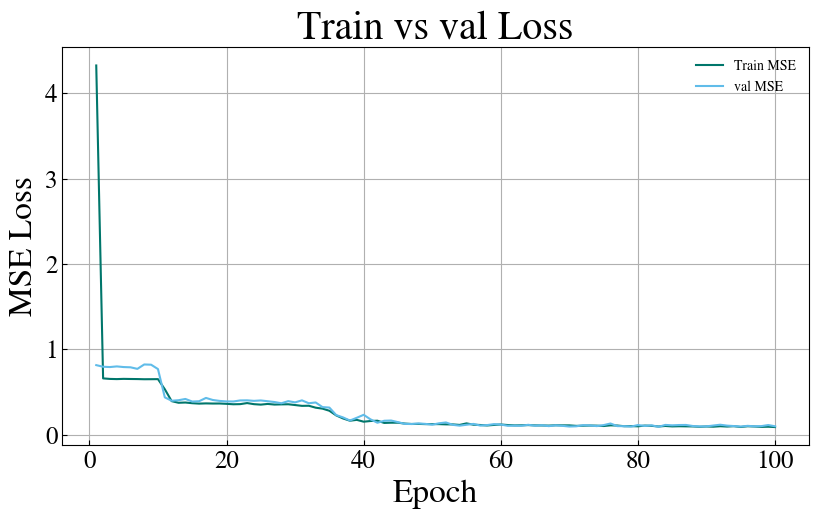

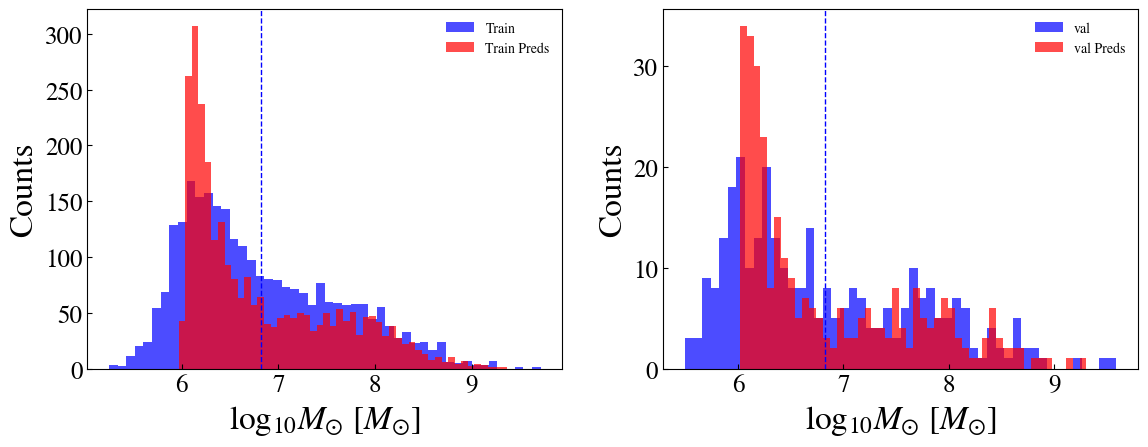

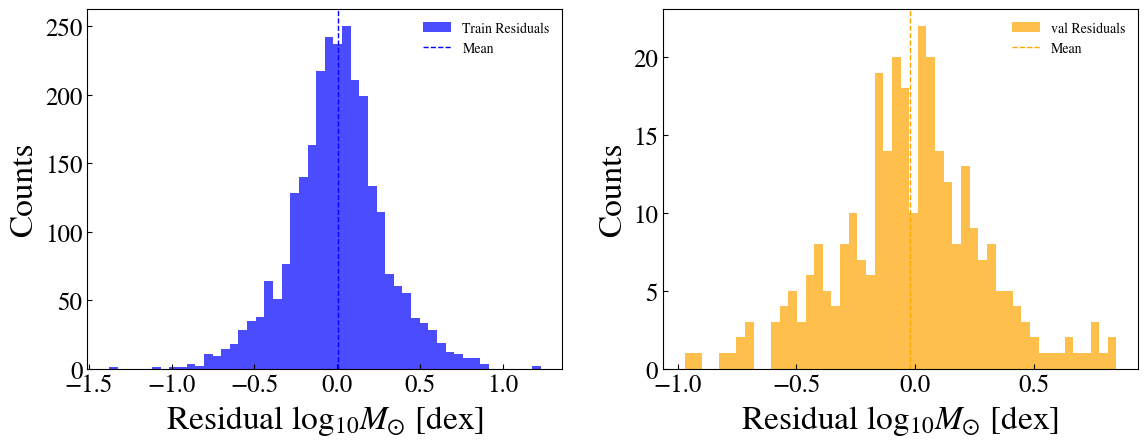

In [67]:
print(np.min(y_val), np.max(y_val))

y_true = y_val_tensor.cpu().numpy().flatten()
y_pred = val_preds_np  # already flattened

r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R² = {r2:.3f}")

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train MSE")
plt.plot(range(1, epochs+1), val_losses, label="val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train vs val Loss")
plt.legend()
plt.grid(True)
plt.show()


bins = 50
# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(y_train, bins=bins, alpha=0.7, color='blue', label='Train')
plt.hist(train_preds, bins=bins, alpha=0.7, color='r', label='Train Preds')
plt.axvline(np.mean(y_train), color='blue', linestyle='dashed', linewidth=1)
plt.xlabel('${\\rm log_{10}}M_{\\odot}$ [$M_{\\odot}$]')
plt.ylabel('Counts')
plt.legend()

plt.subplot(1,2,2)
plt.hist(y_val, bins=bins, alpha=0.7, color='blue', label='val')
plt.hist(val_preds, bins=bins, alpha=0.7, color='r', label='val Preds')
plt.axvline(np.mean(y_val), color='blue', linestyle='dashed', linewidth=1)
plt.xlabel('${\\rm log_{10}}M_{\\odot}$ [$M_{\\odot}$]')
plt.ylabel('Counts')
plt.legend()

plt.tight_layout()
plt.show()



resid_train = y_train - train_preds_np
resid_val = y_val - val_preds_np

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(resid_train, bins=bins, alpha=0.7, color='blue', label='Train Residuals')
plt.axvline(np.mean(resid_train), color='blue', linestyle='dashed', linewidth=1, label='Mean')
plt.xlabel('Residual ${\\rm log_{10}}M_{\\odot}$ [dex]')
plt.ylabel('Counts')
plt.legend()

plt.subplot(1,2,2)
plt.hist(resid_val, bins=bins, alpha=0.7, color='orange', label='val Residuals')
plt.axvline(np.mean(resid_val), color='orange', linestyle='dashed', linewidth=1, label='Mean')
plt.xlabel('Residual ${\\rm log_{10}}M_{\\odot}$ [dex]')
plt.ylabel('Counts')
plt.legend()

plt.tight_layout()
plt.show()

R² = 0.877
MSE = 0.093
RMSE = 0.306


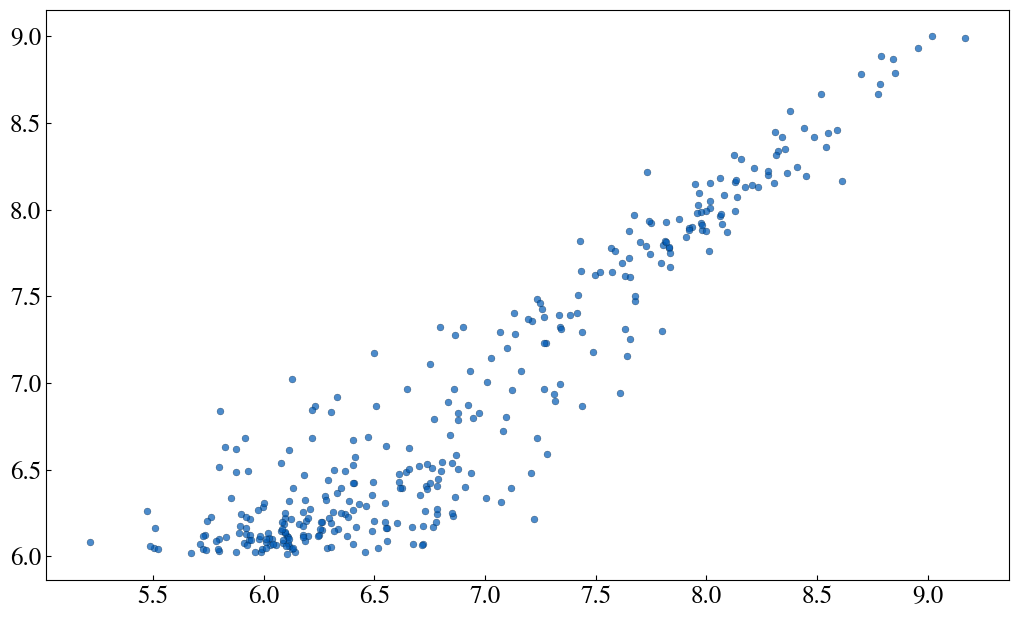

In [68]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    test_preds, test_attention = model(X_test_tensor)
    test_preds_np = test_preds.cpu().numpy().flatten()
    test_labels_np = y_test_tensor.cpu().numpy().flatten()

mse = np.mean((test_preds_np - test_labels_np) ** 2)
rmse = np.sqrt(np.mean((test_preds_np - test_labels_np) ** 2))
r2 = 1 - np.sum((test_labels_np - test_preds_np)**2) / np.sum((test_labels_np - np.mean(test_preds_np))**2)
print(f'R² = {r2:.3f}')
print(f'MSE = {mse:.3f}')
print(f'RMSE = {rmse:.3f}')

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(test_labels_np, test_preds_np, s=25, c='#005AB5', edgecolors='k', linewidths=0.2, alpha=0.7)

Epoch 100: Mean Attention (first 10 timesteps): [4.4195371e-08 3.5507875e-07 9.6652193e-06 7.5903564e-04 7.8525329e-03
 1.8363213e-02 2.8029645e-02 3.9691228e-02 5.1205188e-02 5.8716096e-02]


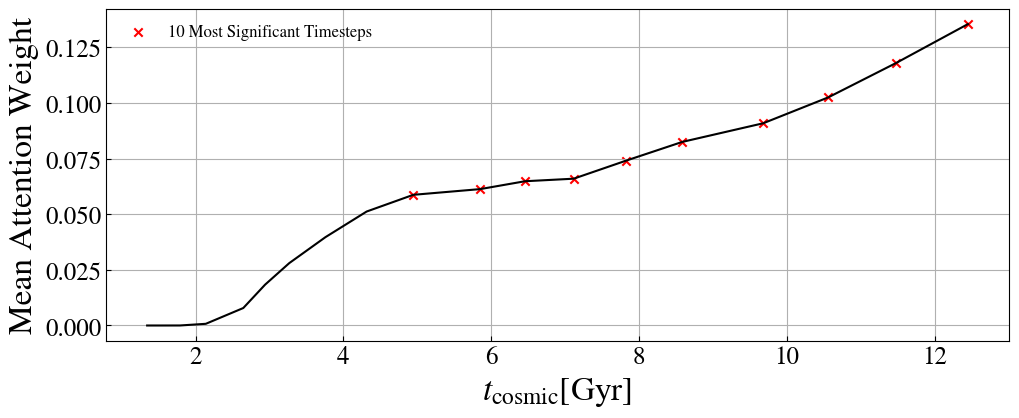

In [69]:
# Average attention per timestep (global importance)
val_attn_weights = val_attention.cpu().numpy()  # shape: (batch_size, cosmic_time)
mean_val_attn_per_t = val_attn_weights.mean(axis=0)  # shape: (cosmic_time,)

print(f"Epoch {epoch+1}: Mean Attention (first 10 timesteps): {mean_val_attn_per_t[:10]}")

most_significant_idx = np.argsort(mean_val_attn_per_t)[-10:]

fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.plot(t_cosmic, mean_val_attn_per_t, c='k')
ax.scatter(t_cosmic[most_significant_idx], mean_val_attn_per_t[most_significant_idx], c='r', marker='x', label='10 Most Significant Timesteps')
ax.set_xlabel('$t_{\\rm cosmic}$[Gyr]', fontsize=24)
ax.set_ylabel('Mean Attention Weight', fontsize=24)
ax.legend(fontsize=12)
ax.grid(True)
plt.show()

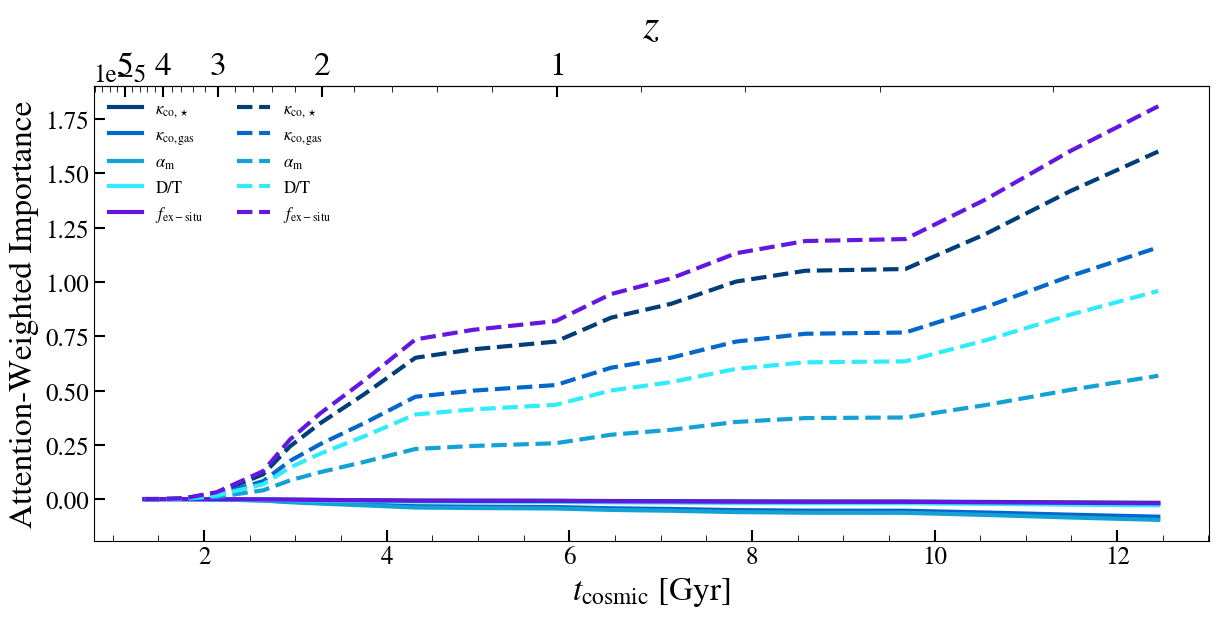

In [57]:
model.eval()

X_val_tensor.requires_grad_(True)

preds, attn = model(X_val_tensor)
loss = preds.mean()
loss.backward()

grads = X_val_tensor.grad.detach().cpu().numpy()  # (N, T, F)

kappa_grad_time_negative = np.mean(grads[:, :, 0][grads[:,:,0] < 0], axis=0)  # (T,)
kappa_grad_time_positive = np.mean(grads[:, :, 0][grads[:,:,0] > 0], axis=0)  # (T,)
kappa_attention_weighted_negative = mean_val_attn_per_t * kappa_grad_time_negative
kappa_attention_weighted_positive = mean_val_attn_per_t * kappa_grad_time_positive

kappa_gas_grad_time_negative = np.mean(grads[:, :, 1][grads[:,:,1] < 0], axis=0)  # (T,)
kappa_gas_grad_time_positive = np.mean(grads[:, :, 1][grads[:,:,1] > 0], axis=0)  # (T,)
kappa_gas_attention_weighted_negative = mean_val_attn_per_t * kappa_gas_grad_time_negative
kappa_gas_attention_weighted_positive = mean_val_attn_per_t * kappa_gas_grad_time_positive

alpha_m_grad_time_negative = np.mean(grads[:, :, 2][grads[:,:,2] < 0], axis=0)  # (T,)
alpha_m_grad_time_positive = np.mean(grads[:, :, 2][grads[:,:,2] > 0], axis=0)  # (T,)
alpha_m_attention_weighted_negative = mean_val_attn_per_t * alpha_m_grad_time_negative
alpha_m_attention_weighted_positive = mean_val_attn_per_t * alpha_m_grad_time_positive

D_T_grad_time_negative = np.mean(grads[:, :, 3][grads[:,:,3] < 0], axis=0)  # (T,)
D_T_grad_time_positive = np.mean(grads[:, :, 3][grads[:,:,3] > 0], axis=0)  # (T,)
D_T_attention_weighted_negative = mean_val_attn_per_t * D_T_grad_time_negative
D_T_attention_weighted_positive = mean_val_attn_per_t * D_T_grad_time_positive

M_acc_grad_time_negative = np.mean(grads[:, :, 4][grads[:,:,4] < 0], axis=0)  # (T,)
M_acc_grad_time_positive = np.mean(grads[:, :, 4][grads[:,:,4] > 0], axis=0)  # (T,)
M_acc_attention_weighted_negative = mean_val_attn_per_t * M_acc_grad_time_negative
M_acc_attention_weighted_positive = mean_val_attn_per_t * M_acc_grad_time_positive

f_exsitu_grad_time_negative = np.mean(grads[:, :, 5][grads[:,:,5] < 0], axis=0)  # (T,)
f_exsitu_grad_time_positive = np.mean(grads[:, :, 5][grads[:,:,5] > 0], axis=0)  # (T,)
f_exsitu_attention_weighted_negative = mean_val_attn_per_t * f_exsitu_grad_time_negative
f_exsitu_attention_weighted_positive = mean_val_attn_per_t * f_exsitu_grad_time_positive

# plt.figure(figsize=(12,6))
# plt.plot(t_cosmic, kappa_attention_weighted, lw=3, c='k')
# plt.xlabel('$t_{\\rm cosmic}$ [Gyr]')
# plt.ylabel('Attention-weighted importance')
# plt.grid(True)
# plt.show()


fig, ax = plt.subplots(1,1, figsize=(12,6))

t_from_z = interp1d(all_redshifts, t_cosmic, kind='linear', fill_value='extrapolate')
z_from_t = interp1d(t_cosmic, all_redshifts, kind='linear', fill_value='extrapolate')
ax2 = ax.secondary_xaxis('top', functions=(z_from_t, t_from_z))
ax2.set_xlabel('$z$', fontsize=30, labelpad=10)
ax2.tick_params(axis='x', labelsize=24)


ax.plot(t_cosmic, kappa_attention_weighted_negative, lw=3, c="#003D79", label='$\\kappa_{\\rm co, \\star}$')
ax.plot(t_cosmic, kappa_gas_attention_weighted_negative, lw=3, c="#0367CB", label='$\\kappa_{\\rm co, gas}$')
ax.plot(t_cosmic, alpha_m_attention_weighted_negative, lw=3, c="#14A2D6", label='$\\alpha_{\\rm m}$')
ax.plot(t_cosmic, D_T_attention_weighted_negative, lw=3, c="#30ECFA", label='D/T')
# ax.plot(t_cosmic, M_acc_attention_weighted_negative, lw=3, c="#3C00FF", label='$M_{\\star, acc}$')
ax.plot(t_cosmic, f_exsitu_attention_weighted_negative, lw=3, c="#6417E0", label='$f_{\\rm ex-situ}$')

ax.plot(t_cosmic, kappa_attention_weighted_positive, ls='--', lw=3, c="#003D79", label='$\\kappa_{\\rm co, \\star}$')
ax.plot(t_cosmic, kappa_gas_attention_weighted_positive, ls='--', lw=3, c="#0367CB", label='$\\kappa_{\\rm co, gas}$')
ax.plot(t_cosmic, alpha_m_attention_weighted_positive, ls='--', lw=3, c="#14A2D6", label='$\\alpha_{\\rm m}$')
ax.plot(t_cosmic, D_T_attention_weighted_positive, ls='--', lw=3, c="#30ECFA", label='D/T')
# ax.plot(t_cosmic, M_acc_attention_weighted_positive, ls='--', lw=3, c="#3C00FF", label='$M_{\\star, acc}$')
ax.plot(t_cosmic, f_exsitu_attention_weighted_positive, ls='--', lw=3, c="#6417E0", label='$f_{\\rm ex-situ}$')
ax.set_xlabel('$t_{\\rm cosmic}$ [Gyr]', fontsize=24)
ax.set_ylabel('Attention-Weighted Importance', fontsize=24)
ax.legend(fontsize=12, ncol=2)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='minor', length=4)
ax2.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', width=1.5, length=8)
ax2.tick_params(axis='both', which='major', width=1.5, length=8)


plt.show()

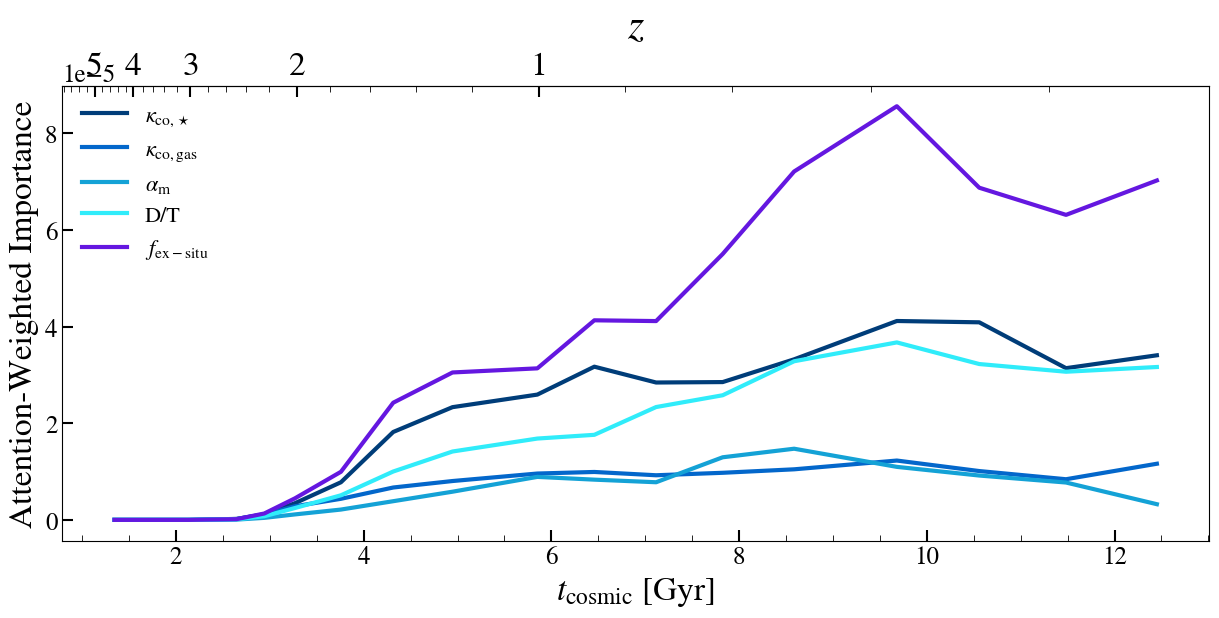

In [81]:
model.eval()
X_subset = X_val_tensor.clone().detach()
X_subset.requires_grad_(True)
preds, attn = model(X_subset)
loss = preds.mean()
loss.backward()

grads = X_subset.grad.detach().cpu().numpy()   # (N, T, F)

median_val_attn_per_t = attn.median(dim=0).values.detach().cpu().numpy()

kappa_grad_time = np.median(np.abs(grads[:, :, 0]), axis=0)  # (T,)
kappa_attention_weighted = median_val_attn_per_t * kappa_grad_time

kappa_gas_grad_time = np.median(np.abs(grads[:, :, 1]), axis=0)  # (T,)
kappa_gas_attention_weighted = median_val_attn_per_t * kappa_gas_grad_time

alpha_m_grad_time = np.median(np.abs(grads[:, :, 2]), axis=0)  # (T,)
alpha_m_attention_weighted = median_val_attn_per_t * alpha_m_grad_time

D_T_grad_time = np.median(np.abs(grads[:, :, 3]), axis=0)  # (T,)
D_T_attention_weighted = median_val_attn_per_t * D_T_grad_time

M_acc_grad_time = np.median(np.abs(grads[:, :, 4]), axis=0)  # (T,)
M_acc_attention_weighted = median_val_attn_per_t * M_acc_grad_time

f_exsitu_grad_time = np.median(np.abs(grads[:, :, 5]), axis=0)  # (T,)
f_exsitu_attention_weighted = median_val_attn_per_t * f_exsitu_grad_time

# plt.figure(figsize=(12,6))
# plt.plot(t_cosmic, kappa_attention_weighted, lw=3, c='k')
# plt.xlabel('$t_{\\rm cosmic}$ [Gyr]')
# plt.ylabel('Attention-weighted importance')
# plt.grid(True)
# plt.show()


fig, ax = plt.subplots(1,1, figsize=(12,6))

t_from_z = interp1d(all_redshifts, t_cosmic, kind='linear', fill_value='extrapolate')
z_from_t = interp1d(t_cosmic, all_redshifts, kind='linear', fill_value='extrapolate')
ax2 = ax.secondary_xaxis('top', functions=(z_from_t, t_from_z))
ax2.set_xlabel('$z$', fontsize=30, labelpad=10)
ax2.tick_params(axis='x', labelsize=24)


ax.plot(t_cosmic, kappa_attention_weighted, lw=3, c="#003D79", label='$\\kappa_{\\rm co, \\star}$')
ax.plot(t_cosmic, kappa_gas_attention_weighted, lw=3, c="#0367CB", label='$\\kappa_{\\rm co, gas}$')
ax.plot(t_cosmic, alpha_m_attention_weighted, lw=3, c="#14A2D6", label='$\\alpha_{\\rm m}$')
ax.plot(t_cosmic, D_T_attention_weighted, lw=3, c="#30ECFA", label='D/T')
# ax.plot(t_cosmic, M_acc_attention_weighted, lw=3, c="#3C00FF", label='$M_{\\star, acc}$')
ax.plot(t_cosmic, f_exsitu_attention_weighted, lw=3, c="#6417E0", label='$f_{\\rm ex-situ}$')
ax.set_xlabel('$t_{\\rm cosmic}$ [Gyr]', fontsize=24)
ax.set_ylabel('Attention-Weighted Importance', fontsize=24)
ax.legend(fontsize=16)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='minor', length=4)
ax2.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', width=1.5, length=8)
ax2.tick_params(axis='both', which='major', width=1.5, length=8)


plt.show()

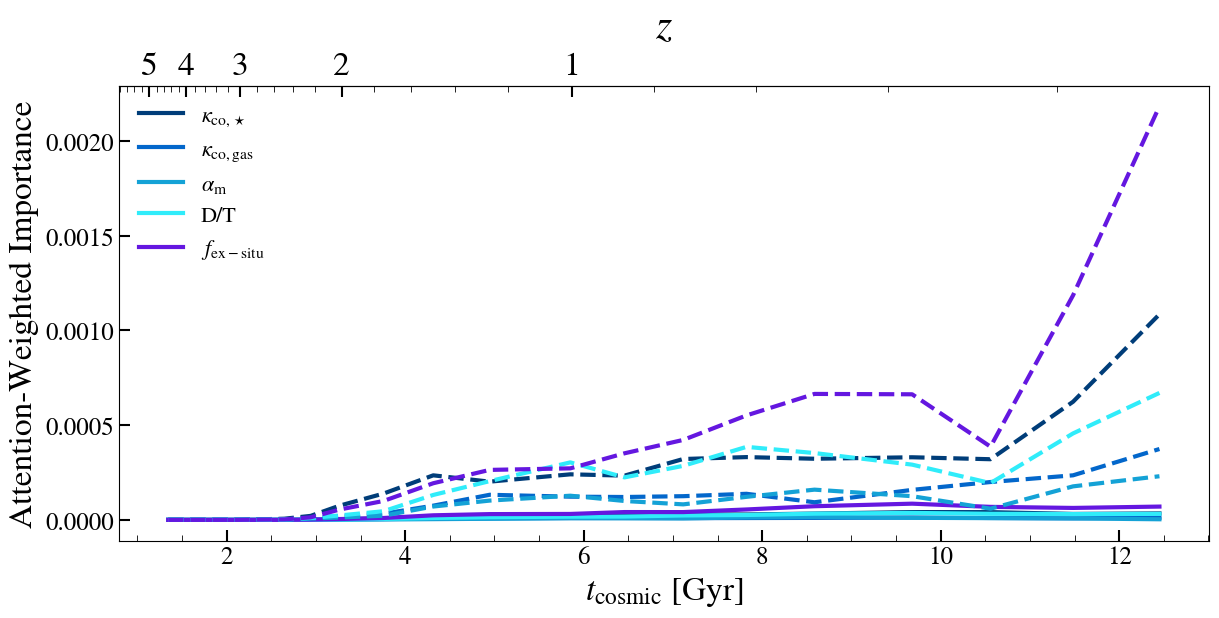

In [89]:
model.eval()

mask = (e_bind_val > 58.0) & (e_bind_val < 58.5)

Xset = X_val_tensor[mask].clone().detach()
Xset.requires_grad_(True)

model.eval()
preds, attn = model(Xset)
loss = preds.mean()
loss.backward()

grads = Xset.grad.detach().cpu().numpy()   # (N, T, F)

medianset_attn_per_t = attn.median(dim=0).values.detach().cpu().numpy()

kappa_grad_time = np.median(np.abs(grads[:, :, 0]), axis=0)  # (T,)
kappa_attention_weighted_subset = medianset_attn_per_t * kappa_grad_time

kappa_gas_grad_time = np.median(np.abs(grads[:, :, 1]), axis=0)  # (T,)
kappa_gas_attention_weighted_subset = medianset_attn_per_t * kappa_gas_grad_time

alpha_m_grad_time = np.median(np.abs(grads[:, :, 2]), axis=0)  # (T,)
alpha_m_attention_weighted_subset = medianset_attn_per_t * alpha_m_grad_time

D_T_grad_time = np.median(np.abs(grads[:, :, 3]), axis=0)  # (T,)
D_T_attention_weighted_subset = medianset_attn_per_t * D_T_grad_time

M_acc_grad_time = np.median(np.abs(grads[:, :, 4]), axis=0)  # (T,)
M_acc_attention_weighted_subset = medianset_attn_per_t * M_acc_grad_time

f_exsitu_grad_time = np.median(np.abs(grads[:, :, 5]), axis=0)  # (T,)
f_exsitu_attention_weighted_subset = medianset_attn_per_t * f_exsitu_grad_time



model.eval()
Xset = X_val_tensor.clone().detach()
Xset.requires_grad_(True)
preds, attn = model(Xset)
loss = preds.mean()
loss.backward()

grads = Xset.grad.detach().cpu().numpy()   # (N, T, F)

median_val_attn_per_t = attn.median(dim=0).values.detach().cpu().numpy()

kappa_grad_time = np.median(np.abs(grads[:, :, 0]), axis=0)  # (T,)
kappa_attention_weighted = median_val_attn_per_t * kappa_grad_time

kappa_gas_grad_time = np.median(np.abs(grads[:, :, 1]), axis=0)  # (T,)
kappa_gas_attention_weighted = median_val_attn_per_t * kappa_gas_grad_time

alpha_m_grad_time = np.median(np.abs(grads[:, :, 2]), axis=0)  # (T,)
alpha_m_attention_weighted = median_val_attn_per_t * alpha_m_grad_time

D_T_grad_time = np.median(np.abs(grads[:, :, 3]), axis=0)  # (T,)
D_T_attention_weighted = median_val_attn_per_t * D_T_grad_time

M_acc_grad_time = np.median(np.abs(grads[:, :, 4]), axis=0)  # (T,)
M_acc_attention_weighted = median_val_attn_per_t * M_acc_grad_time

f_exsitu_grad_time = np.median(np.abs(grads[:, :, 5]), axis=0)  # (T,)
f_exsitu_attention_weighted = median_val_attn_per_t * f_exsitu_grad_time


fig, ax = plt.subplots(1,1, figsize=(12,6))

t_from_z = interp1d(all_redshifts, t_cosmic, kind='linear', fill_value='extrapolate')
z_from_t = interp1d(t_cosmic, all_redshifts, kind='linear', fill_value='extrapolate')
ax2 = ax.secondary_xaxis('top', functions=(z_from_t, t_from_z))
ax2.set_xlabel('$z$', fontsize=30, labelpad=10)
ax2.tick_params(axis='x', labelsize=24)


ax.plot(t_cosmic, kappa_attention_weighted, lw=3, c="#003D79", label='$\\kappa_{\\rm co, \\star}$')
ax.plot(t_cosmic, kappa_gas_attention_weighted, lw=3, c="#0367CB", label='$\\kappa_{\\rm co, gas}$')
ax.plot(t_cosmic, alpha_m_attention_weighted, lw=3, c="#14A2D6", label='$\\alpha_{\\rm m}$')
ax.plot(t_cosmic, D_T_attention_weighted, lw=3, c="#30ECFA", label='D/T')
# ax.plot(t_cosmic, M_acc_attention_weighted, lw=3, c="#3C00FF", label='$M_{\\star, acc}$')
ax.plot(t_cosmic, f_exsitu_attention_weighted, lw=3, c="#6417E0", label='$f_{\\rm ex-situ}$')

ax.plot(t_cosmic, kappa_attention_weighted_subset, lw=3, ls='--', c="#003D79")
ax.plot(t_cosmic, kappa_gas_attention_weighted_subset, lw=3, ls='--', c="#0367CB")
ax.plot(t_cosmic, alpha_m_attention_weighted_subset, lw=3, ls='--', c="#14A2D6")
ax.plot(t_cosmic, D_T_attention_weighted_subset, lw=3, ls='--', c="#30ECFA")
# ax.plot(t_cosmic, M_acc_attention_weighted_subset, lw=3, ls='--', c="#3C00FF")
ax.plot(t_cosmic, f_exsitu_attention_weighted_subset, lw=3, ls='--', c="#6417E0")
ax.set_xlabel('$t_{\\rm cosmic}$ [Gyr]', fontsize=24)
ax.set_ylabel('Attention-Weighted Importance', fontsize=24)
ax.legend(fontsize=16)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='minor', length=4)
ax2.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', width=1.5, length=8)
ax2.tick_params(axis='both', which='major', width=1.5, length=8)


plt.show()